# Modelo de Admisión de Riesgo de Crédito Minorista
### Fase 3 - Scorecard e impacto de negocio

**Autor:** Adrian Sabin Pelayo · Data Science | Riesgo de Crédito
**Ámbito:** Banca minorista - admisión y scoring de particulares

---

## Resumen ejecutivo

Las fases 1 y 2 dejaron la cartera depurada y un modelo que estima la probabilidad de impago (PD). Esta fase convierte ese modelo en dos entregables operativos:

| Entregable | Qué es |
|---|---|
| **Scorecard 300–850** | La PD traducida a puntuación de crédito, escala estándar del sector |
| **Simulación de cartera** | Pérdida evitada en euros frente al escenario sin modelo |

Cierra el proyecto respondiendo a la pregunta de la dirección: **¿qué gana el banco con esto?**

## 1. Carga del modelo entrenado

Se recuperan los artefactos serializados en la fase 2: modelo afinado y predicciones sobre el conjunto de test. Entrenar una vez y reutilizar es como operan los equipos de riesgo en producción.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import json
import warnings
warnings.filterwarnings("ignore")

# Paleta corporativa
COLOR_PRINCIPAL = "#4A90D9"   # Azul institucional
COLOR_ALERTA    = "#E05C5C"   # Rojo de alerta
COLOR_NEUTRO    = "#7F8C99"   # Gris secundario

COLOR_RATING = {
    "E - Muy alto": "#E05C5C",   # rojo
    "D - Alto":     "#E8A87C",   # naranja
    "C - Medio":    "#7F8C99",   # gris
    "B - Bajo":     "#4A90D9",   # azul
    "A - Muy bajo": "#2E6DA4",   # azul oscuro
}

plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 90

# Modelo y resultados guardados en la fase de modelado
lgbm_tuned = joblib.load("data/modelo_lgbm.pkl")
y_prob = np.load("data/y_prob.npy")
y_test = pd.Series(np.load("data/y_test.npy"))

print("Modelo y resultados cargados correctamente.")

Modelo y resultados cargados correctamente.


> **Requisito:** la fase 2 debe haber guardado `modelo_lgbm.pkl`, `y_prob.npy` e `y_test.npy` y la "política" de concesión de crédito.

## 2. De la PD a la puntuación de crédito

La PD es correcta pero no es operativa: un gestor ve `0.0196` y no sabe si eso es bueno. Además la escala está aplastada - casi toda la cartera vive entre 0 y 0,1, y las diferencias que importan ocurren en decimales.

La solución del sector es la transformación **PDO (points to double the odds)**, en tres pasos:

**1 · Probabilidad → odds.** `odds = (1 − PD) / PD`, es decir, buenos pagadores por cada moroso. Una PD del 2% son odds de 49:1.

**2 · Odds → logaritmo.** Como `ln(2x) = ln(x) + ln(2)`, **duplicar las odds pasa a ser sumar una constante**. La escala multiplicativa se vuelve aditiva.

**3 · Reescalado lineal a 300–850.**

$$\text{Score} = \text{offset} + \text{factor}\cdot\ln(\text{odds}), \qquad \text{factor} = \frac{PDO}{\ln 2}$$

Los dos parámetros se fijan con dos anclas de negocio:

| Parámetro | Qué fija | Valor |
|---|---|---|
| `PDO = 20` | Puntos que vale duplicar las odds | factor ≈ 28,85 |
| `base_score = 600` ≡ `base_odds = 50` | Dónde se ancla la escala | offset ≈ 487 |

**Resultado:** 600 puntos ≡ odds 50:1 (PD ≈ 2%), y **cada +20 puntos duplican las odds**:

| Score | 560 | 580 | 600 | 620 | 640 |
|---|---|---|---|---|---|
| **Odds** | 12:1 | 25:1 | 50:1 | 100:1 | 200:1 |
| **PD** | 7,4% | 3,8% | 2,0% | 1,0% | 0,5% |

Los pasos de score son constantes; la PD se divide por dos en cada uno. **El score es lineal en log-odds, no en probabilidad.**

### Por qué esta escala y no un reescalado directo de la PD

- **Interpretabilidad constante** - 40 puntos significan "riesgo 4 veces menor" en cualquier tramo de la escala. Con un reescalado lineal de la PD, 40 puntos valdrían cosas distintas en cada zona.
- **Resolución donde importa** - el logaritmo expande la zona de PD baja, que concentra la cartera y donde se decide el pricing.
- **Aditividad** - es la propiedad que hace posibles las scorecards clásicas del tipo "mora previa: −40 puntos". Convención del sector y compatibilidad con los sistemas de admisión existentes.

> `np.clip(score, 300, 850)` acota los extremos: una PD de 1e-6 daría ~880 puntos. Comprime la cola superior, sin impacto práctico -  todos esos clientes son "aprobar".

Con la cartera puntuada se pueden fijar políticas por tramos ("aprobación automática por encima de X puntos").

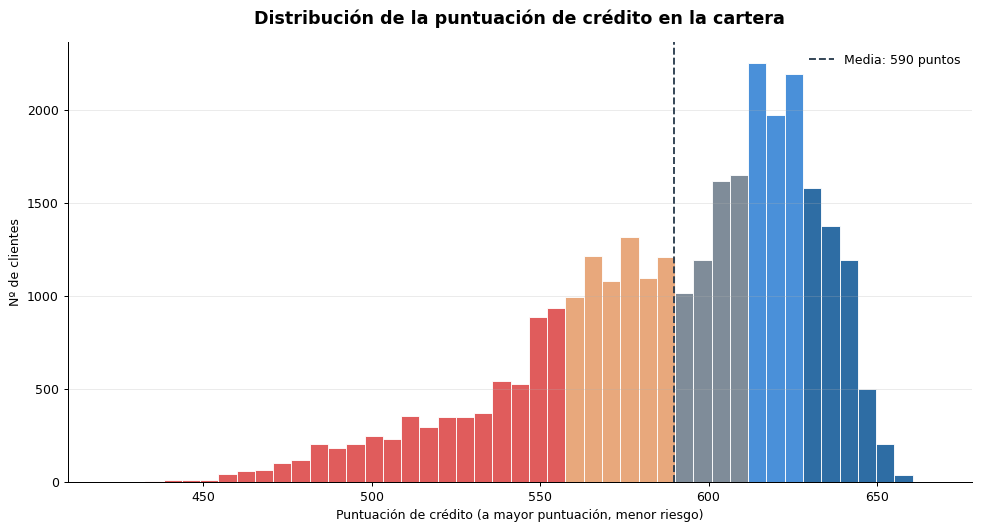

In [2]:
def pd_to_score(pd_array, base_score=600, base_odds=50, pdo=20):
    pd_array = np.clip(pd_array, 1e-6, 1 - 1e-6)
    odds = (1 - pd_array) / pd_array
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    score = offset + factor * np.log(odds)
    return np.clip(score, 300, 850).round().astype(int)

scores = pd_to_score(y_prob)

plt.figure(figsize=(11, 6))
n, bins, patches = plt.hist(scores, bins=45, edgecolor="white", linewidth=0.7)

limite_E, limite_D, limite_C, limite_B = np.percentile(scores, [20, 40, 60, 80])

for bin_izq, p in zip(bins[:-1], patches):
    if   bin_izq < limite_E: p.set_facecolor(COLOR_RATING["E - Muy alto"])
    elif bin_izq < limite_D: p.set_facecolor(COLOR_RATING["D - Alto"])
    elif bin_izq < limite_C: p.set_facecolor(COLOR_RATING["C - Medio"])
    elif bin_izq < limite_B: p.set_facecolor(COLOR_RATING["B - Bajo"])
    else:                    p.set_facecolor(COLOR_RATING["A - Muy bajo"])

linea_media = plt.axvline(scores.mean(), color="#2C3E50", ls="--", lw=1.5,
                          label=f"Media: {scores.mean():.0f} puntos")

plt.title("Distribución de la puntuación de crédito en la cartera", fontsize=14, pad=15)
plt.xlabel("Puntuación de crédito (a mayor puntuación, menor riesgo)")
plt.ylabel("Nº de clientes")
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Lectura de negocio

La distribución se concentra en puntuaciones altas - cartera mayoritariamente sana, coherente con la fase 1. La cola izquierda aísla al grupo reducido que concentra el riesgo y sobre el que aplicar controles reforzados.

## 3. Segmentación en niveles de riesgo

La dirección decide por **segmentos**, no por cliente. Se agrupa la cartera en cinco tramos de rating (A mejor, E peor) sobre los cortes habituales de la escala 300–850.

Para cada tramo se compara la **PD media estimada** con la **tasa de mora realmente observada**. Es la prueba de calibración del scorecard: si está bien construido, la morosidad real debe crecer de forma monótona de A a E.

In [3]:
resultados_df = pd.DataFrame({
    "score": scores,
    "PD": y_prob,
    "default_real": y_test.values
})

resultados_df["rating"] = pd.qcut(
    resultados_df["score"], q=5,
    labels=["E - Muy alto", "D - Alto", "C - Medio", "B - Bajo", "A - Muy bajo"]
)

tabla_ratings = resultados_df.groupby("rating").agg(
    n_clientes=("score", "count"),
    pct_cartera=("score", lambda x: 100 * len(x) / len(resultados_df)),
    PD_media=("PD", "mean"),
    tasa_default_real=("default_real", "mean")
).round(4)

print(tabla_ratings)

              n_clientes  pct_cartera  PD_media  tasa_default_real
rating                                                            
E - Muy alto        6141      20.5639    0.2376             0.2355
D - Alto            5904      19.7703    0.0521             0.0540
C - Medio           6147      20.5840    0.0207             0.0210
B - Bajo            5715      19.1374    0.0107             0.0122
A - Muy bajo        5956      19.9444    0.0059             0.0064


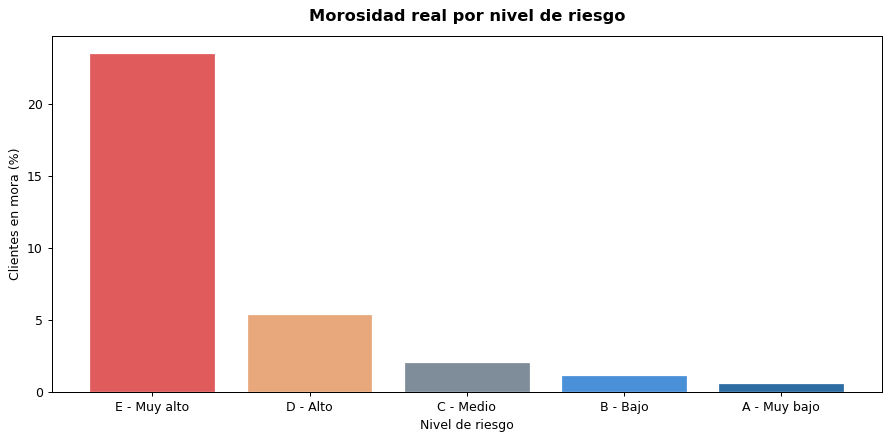

In [4]:
# Validación visual: la morosidad real debe aumentar del rating A al E
plt.figure(figsize=(10, 5))
tasa = resultados_df.groupby("rating")["default_real"].mean() * 100
colores = [COLOR_RATING[str(r)] for r in tasa.index]
plt.bar(tasa.index.astype(str), tasa.values, color=colores, edgecolor="white")
plt.title("Morosidad real por nivel de riesgo", fontsize=13, pad=12)
plt.ylabel("Clientes en mora (%)")
plt.xlabel("Nivel de riesgo")
plt.tight_layout()
plt.show()

### Lectura de negocio

El modelo acierta en la clasificacion del riesgo: cuando anticipa que un grupo fallará un 5%, falla un 5%. Y separa con fuerza el peor quintil de la cartera acumula **37 veces más morosidad** que el mejor.

| Rating | De cada 100 clientes, impagan | Política de admisión |
|---|---|---|
| **A** | 0,6 | Aprobación automática, mejor precio |
| **B** | 1,2 | Aprobación automática |
| **C** | 2,1 | Circuito estándar |
| **D** | 5,4 | Condiciones ajustadas o garantías |
| **E** | 23,6 | Denegación o análisis individual |

La admisión deja de ser un sí o un no. Cada tramo tiene su tratamiento, y el precio puede subir con el riesgo en lugar de que los buenos clientes subvencionen a los malos.


## 4. Simulación de cartera: ¿cuánto ahorra el banco?

Se comparan dos escenarios sobre el mismo conjunto de test:

| Escenario | Política | Pérdida |
|---|---|---|
| **Sin modelo** | Aprobar a todos | Todos los morosos generan pérdida |
| **Con modelo** | Umbral óptimo de la fase 2 | `FN·20.000 € + FP·1.000 €` |

La diferencia es el **ahorro directo** del proyecto. Se mantienen los costes de la fase 2: 20.000 € por impago no detectado, 1.000 € por buen cliente rechazado.

In [5]:

politica  = json.load(open("data/politica.json"))
THRESHOLD = politica["threshold_optimo"]   # Nivel de exigencia óptimo hallado en la fase de modelado
COSTE_FN  = politica["coste_fn"]  # Pérdida por impago NO detectado
COSTE_FP  = politica["coste_fp"]   # Coste de oportunidad por rechazar a un buen cliente

# Decisión del modelo sobre los clientes de evaluación
y_pred_final = (y_prob >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

# Coste del banco CON modelo
coste_fn_total = fn * COSTE_FN
coste_fp_total = fp * COSTE_FP
coste_total = coste_fn_total + coste_fp_total

# Coste del banco SIN modelo (se aprueba a todos: todos los morosos generan pérdida)
coste_sin_modelo = (tp + fn) * COSTE_FN
ahorro = coste_sin_modelo - coste_total

print("="*58)
print(f" SIMULACIÓN DE CARTERA  ·  nivel de exigencia = {THRESHOLD}")
print("="*58)
print(f" Clientes aprobados:                {tn + fn:>10,}")
print(f" Clientes rechazados:               {tp + fp:>10,}")
print("-"*58)
print(f" Morosos detectados a tiempo:       {tp:>10,}")
print(f" Morosos que se cuelan:             {fn:>10,}")
print(f" Buenos clientes rechazados:        {fp:>10,}")
print("-"*58)
print(f" Pérdida por morosos no detectados: {coste_fn_total:>12,.0f} €")
print(f" Coste por rechazos incorrectos:    {coste_fp_total:>12,.0f} €")
print(f" COSTE TOTAL CON MODELO:            {coste_total:>12,.0f} €")
print("-"*58)
print(f" Coste SIN modelo (aprobar a todos):{coste_sin_modelo:>12,.0f} €")
print(f" AHORRO gracias al modelo:          {ahorro:>12,.0f} €")
print(f" Reducción de la pérdida:           {100*ahorro/coste_sin_modelo:>11.1f} %")
print("="*58)

 SIMULACIÓN DE CARTERA  ·  nivel de exigencia = 0.05
 Clientes aprobados:                    20,710
 Clientes rechazados:                    9,153
----------------------------------------------------------
 Morosos detectados a tiempo:            1,647
 Morosos que se cuelan:                    355
 Buenos clientes rechazados:             7,506
----------------------------------------------------------
 Pérdida por morosos no detectados:    7,100,000 €
 Coste por rechazos incorrectos:       7,506,000 €
 COSTE TOTAL CON MODELO:              14,606,000 €
----------------------------------------------------------
 Coste SIN modelo (aprobar a todos):  40,040,000 €
 AHORRO gracias al modelo:            25,434,000 €
 Reducción de la pérdida:                  63.5 %


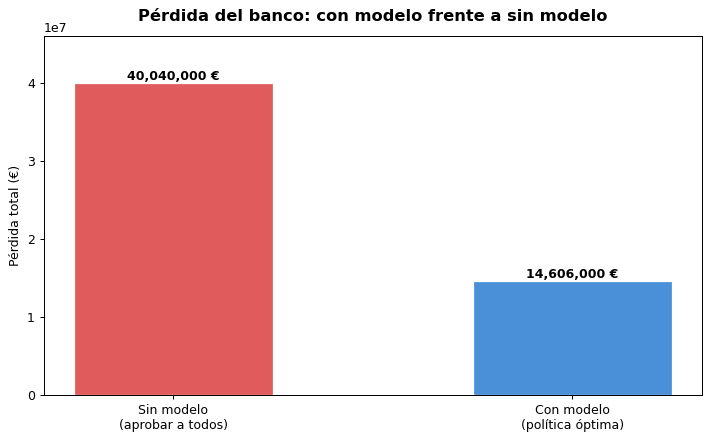

In [6]:
# Comparación visual del coste en ambos escenarios
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(
    ["Sin modelo\n(aprobar a todos)", "Con modelo\n(política óptima)"],
    [coste_sin_modelo, coste_total],
    color=[COLOR_ALERTA, COLOR_PRINCIPAL], edgecolor="white", width=0.5
)
ax.set_title("Pérdida del banco: con modelo frente a sin modelo", fontsize=13, pad=12)
ax.set_ylabel("Pérdida total (€)")
for b, v in zip(barras, [coste_sin_modelo, coste_total]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f} €",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, coste_sin_modelo * 1.15)
plt.tight_layout()
plt.show()

### Lectura de negocio

El modelo **reduce sustancialmente la pérdida** frente a no filtrar. El ahorro viene de interceptar a la mayoría de los morosos: el capital no recuperado pesa mucho más que el margen que se cede al rechazar a algún buen cliente.

Matiz importante para la dirección: la cifra **no es un ingreso, es una pérdida evitada**. En riesgo de crédito, evitar pérdida es precisamente el objetivo del área.

## 5. Conclusiones y recomendaciones

### Qué aporta esta fase

1. **Scorecard 300–850** - la PD convertida en una puntuación operativa y comunicable.
2. **Segmentación en 5 ratings**, validada contra la morosidad observada.
3. **Cuantificación en euros** del valor del modelo frente a no usarlo.

### Recomendaciones

| Recomendación | Por qué |
|---|---|
| Usar el scorecard como base de la admisión | Traduce el riesgo al lenguaje de gestores y comités |
| Aplicar risk-based pricing por rating | Mejora la rentabilidad ajustada al riesgo |
| Automatizar la aprobación de A y B | Agiliza la concesión de clientes seguros |
| Validar los costes con el área financiera | El ahorro depende de las cifras reales de pérdida y margen |
| Recalibrar el scorecard periódicamente | El comportamiento de la cartera deriva con el tiempo |

### Cierre del proyecto

El sistema completo parte de datos en bruto, los depura, estima la PD de cada solicitante, la convierte en puntuación de crédito y la traduce en una decisión de concesión que minimiza la pérdida. Paso siguiente: validación por el área de riesgos antes de producción.